<font size=7 color="green" face="monster">Random Forest from scratch 🌲🌳🌲</font>

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Test/Csv/healthcare-dataset-stroke-data.csv")
print(f"Shape of dataset: {df.shape}")
df.head()

Shape of dataset: (5110, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [ ]:
df.tail()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0
5109,44679,Female,44.0,0,0,Yes,Govt_job,Urban,85.28,26.2,Unknown,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [ ]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [ ]:
df.describe(include=object).T

,count,unique,top,freq
gender,5110,3,Female,2994
ever_married,5110,2,Yes,3353
work_type,5110,5,Private,2925
Residence_type,5110,2,Urban,2596
smoking_status,5110,4,never smoked,1892


In [ ]:
df.isnull().sum().to_frame().T

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,0,0,0,0,0,0,0,0,0,201,0,0


In [ ]:
duplicated = df.duplicated().sum()

print(f"There are {duplicated} duplicated {df.shape[0]} rows in the dataset")

There are 0 duplicated 5110 rows in the dataset


In [ ]:
print("The value of gender: ")
print(df["gender"].value_counts())

The value of gender: 
gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64


In [ ]:
print("The value of ever_married: ")
print(df["ever_married"].value_counts())

The value of ever_married: 
ever_married
Yes    3353
No     1757
Name: count, dtype: int64


In [ ]:
print("The value of work_type: ")
print(df["work_type"].value_counts())

The value of work_type: 
work_type
Private          2925
Self-employed     819
children          687
Govt_job          657
Never_worked       22
Name: count, dtype: int64


In [ ]:
print("The value of Smoking_status: ")
print(df["smoking_status"].value_counts())

The value of Smoking_status: 
smoking_status
never smoked       1892
Unknown            1544
formerly smoked     885
smokes              789
Name: count, dtype: int64


In [ ]:
df = df[df["gender"] != "Other"]

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5109 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5109 non-null   int64  
 1   gender             5109 non-null   object 
 2   age                5109 non-null   float64
 3   hypertension       5109 non-null   int64  
 4   heart_disease      5109 non-null   int64  
 5   ever_married       5109 non-null   object 
 6   work_type          5109 non-null   object 
 7   Residence_type     5109 non-null   object 
 8   avg_glucose_level  5109 non-null   float64
 9   bmi                4908 non-null   float64
 10  smoking_status     5109 non-null   object 
 11  stroke             5109 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 518.9+ KB


## Visualization

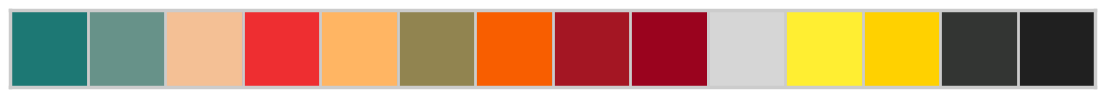

In [ ]:
sns.set_style("whitegrid")
sns.set_context("poster",font_scale = .7)

palette = ["#1d7874","#679289","#f4c095","#ee2e31","#ffb563","#918450","#f85e00","#a41623","#9a031e","#d6d6d6","#ffee32","#ffd100","#333533","#202020"]

sns.palplot(sns.color_palette(palette))
plt.show()

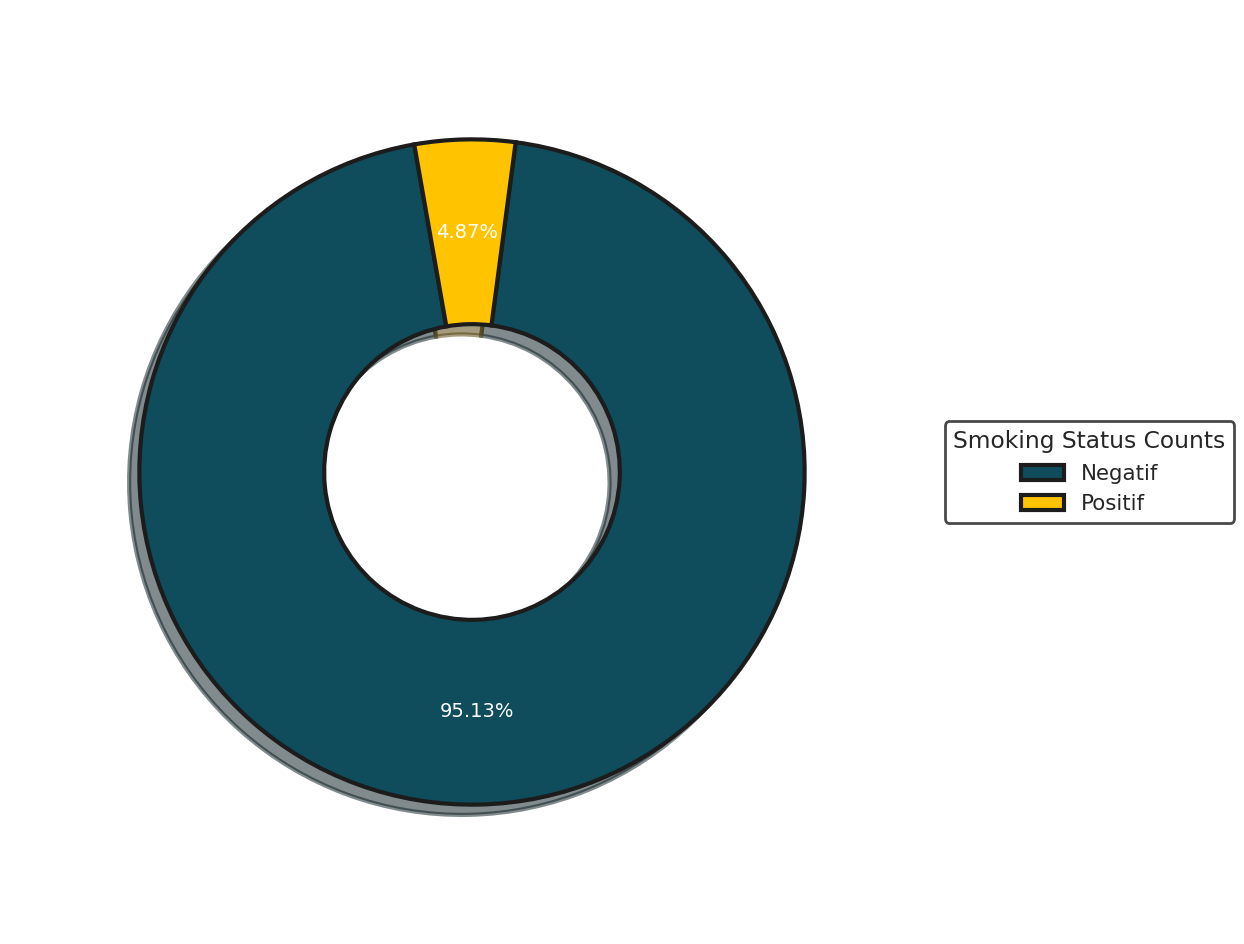

In [ ]:
stroke_count = df.stroke.value_counts()
plt.subplots(figsize=(12,12))
Label = "Negatif", "Positif"
size = 0.5

wedges, texts, autotexts = plt.pie([stroke_count.iloc[0], stroke_count.iloc[1]],
                                   explode=(0.0, 0.0),
                                   autopct='%.2f%%',
                                   shadow=True,
                                   pctdistance=0.72,
                                   radius=.9,
                                   colors = ["#0f4c5c","#FFC300"],
                                   wedgeprops=dict(width=size, edgecolor='#1c1c1c', linewidth=3),
                                   textprops=dict(color="white", size=14),
                                   startangle=100)
plt.legend(wedges, Label, title='Smoking Status Counts', loc='center left', bbox_to_anchor=(1, 0, 0.5, 1), edgecolor="#1c1c1c")
plt.show()

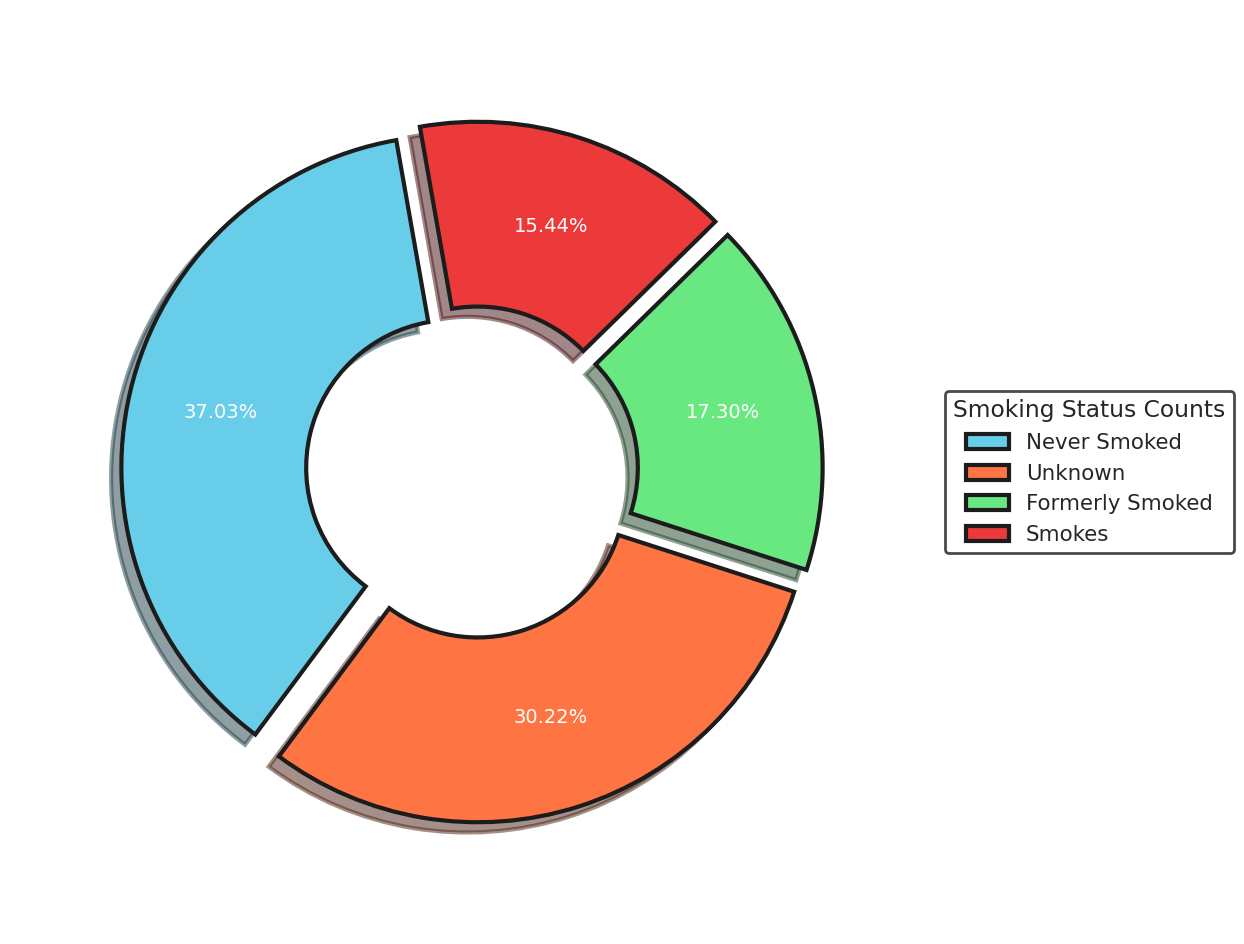

In [ ]:
smoking_status_count = df.smoking_status.value_counts()
plt.subplots(figsize=(12,12))
Label = "Never Smoked", "Unknown", "Formerly Smoked", "Smokes"
size = 0.5

wedges, texts, autotexts = plt.pie([smoking_status_count.iloc[0], smoking_status_count.iloc[1], smoking_status_count.iloc[2], smoking_status_count.iloc[3]],
                                   explode=(0.05, 0.05, 0.05, 0.05),
                                   autopct='%.2f%%',
                                   shadow=True,
                                   pctdistance=0.72,
                                   radius=.9,
                                   colors=['#68cde9', '#fe7443', '#69e781', '#ec3a3b'],
                                   wedgeprops=dict(width=size, edgecolor='#1c1c1c', linewidth=3),
                                   textprops=dict(color="white", size=14),
                                   startangle=100)
plt.legend(wedges, Label, title='Smoking Status Counts', loc='center left', bbox_to_anchor=(1, 0, 0.5, 1), edgecolor="#1c1c1c")
plt.show()

Let's have a look on the work type :


<ipython-input-37-20eb4ed2d90a>:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  p.axes.set_yticklabels(p.get_yticklabels(),rotation = 0)


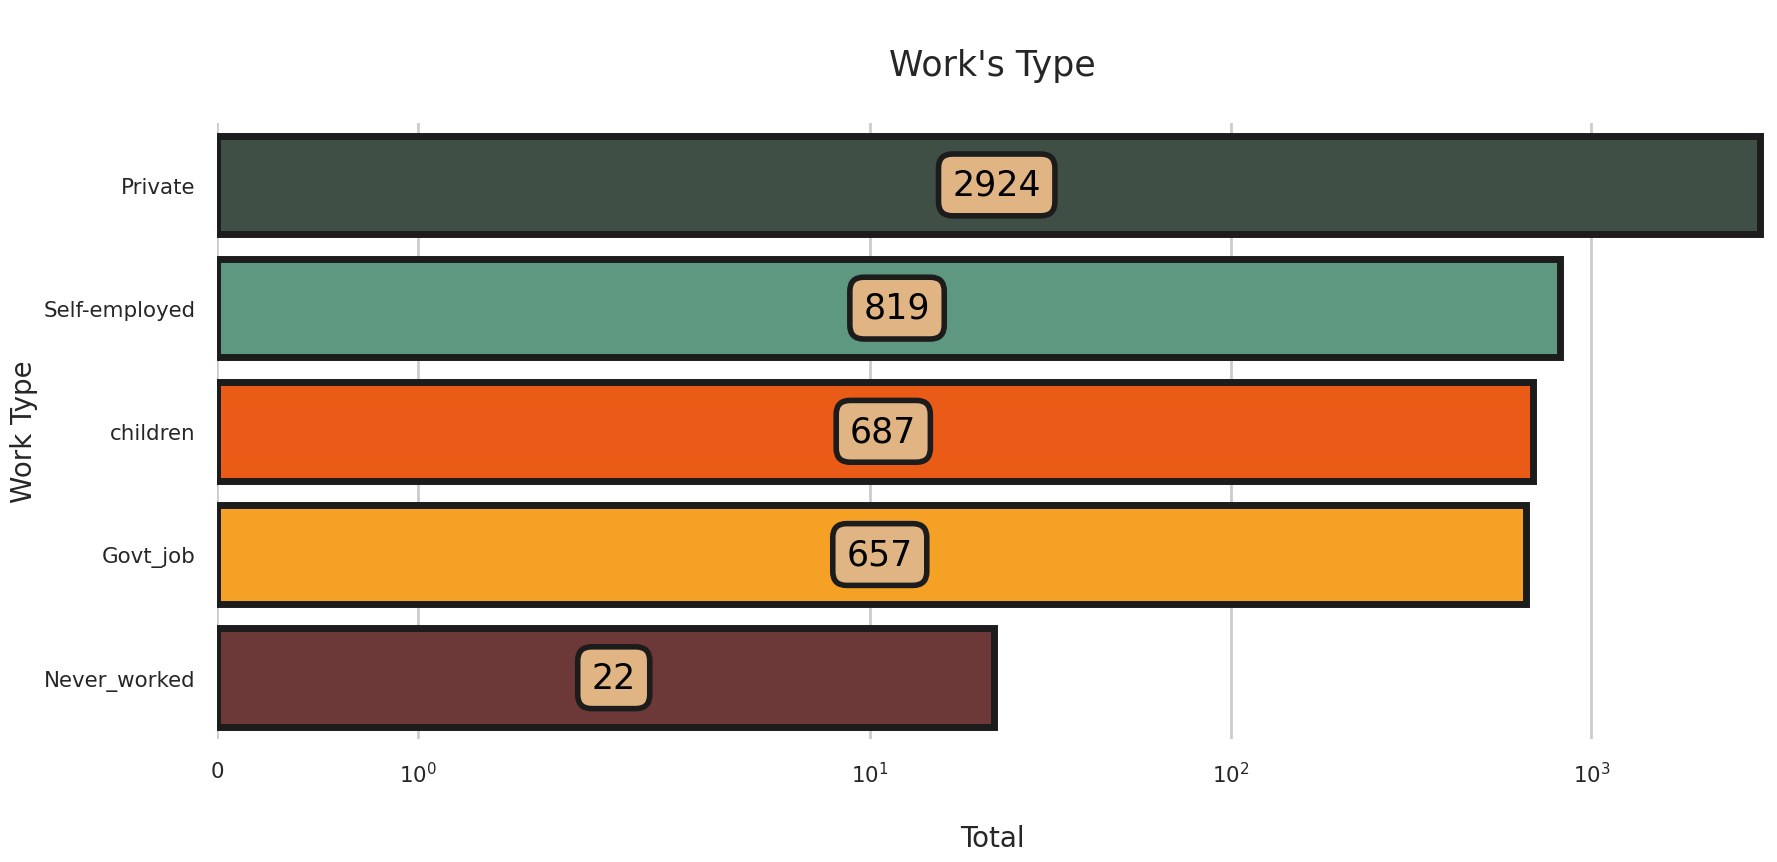

In [ ]:
print("Let's have a look on the work type :")
plt.subplots(figsize=(20, 8))
p=sns.countplot(y=df["work_type"],order=df["work_type"].value_counts().index, hue=df["work_type"], palette=["#3f4f45","#5e9880","#f5a126","#ea5b17","#6c3938"], saturation=1, edgecolor = "#1c1c1c", linewidth = 5)
p.axes.set_xscale("symlog")
p.axes.set_title("\nWork's Type\n",fontsize=25)
p.axes.set_ylabel("Work Type",fontsize=20)
p.axes.set_xlabel("\nTotal",fontsize=20)
p.axes.set_yticklabels(p.get_yticklabels(),rotation = 0)
for container in p.containers:
    p.bar_label(container, label_type="center", padding=6,size=25, color="black", rotation=0,
    bbox={"boxstyle": "round", "pad": 0.4, "facecolor": "#e0b583", "edgecolor": "#1c1c1c", "linewidth" : 4, "alpha": 1})


sns.despine(left=True, bottom=True)
plt.show()

In [ ]:
data_positif = df[df["stroke"] == 1]

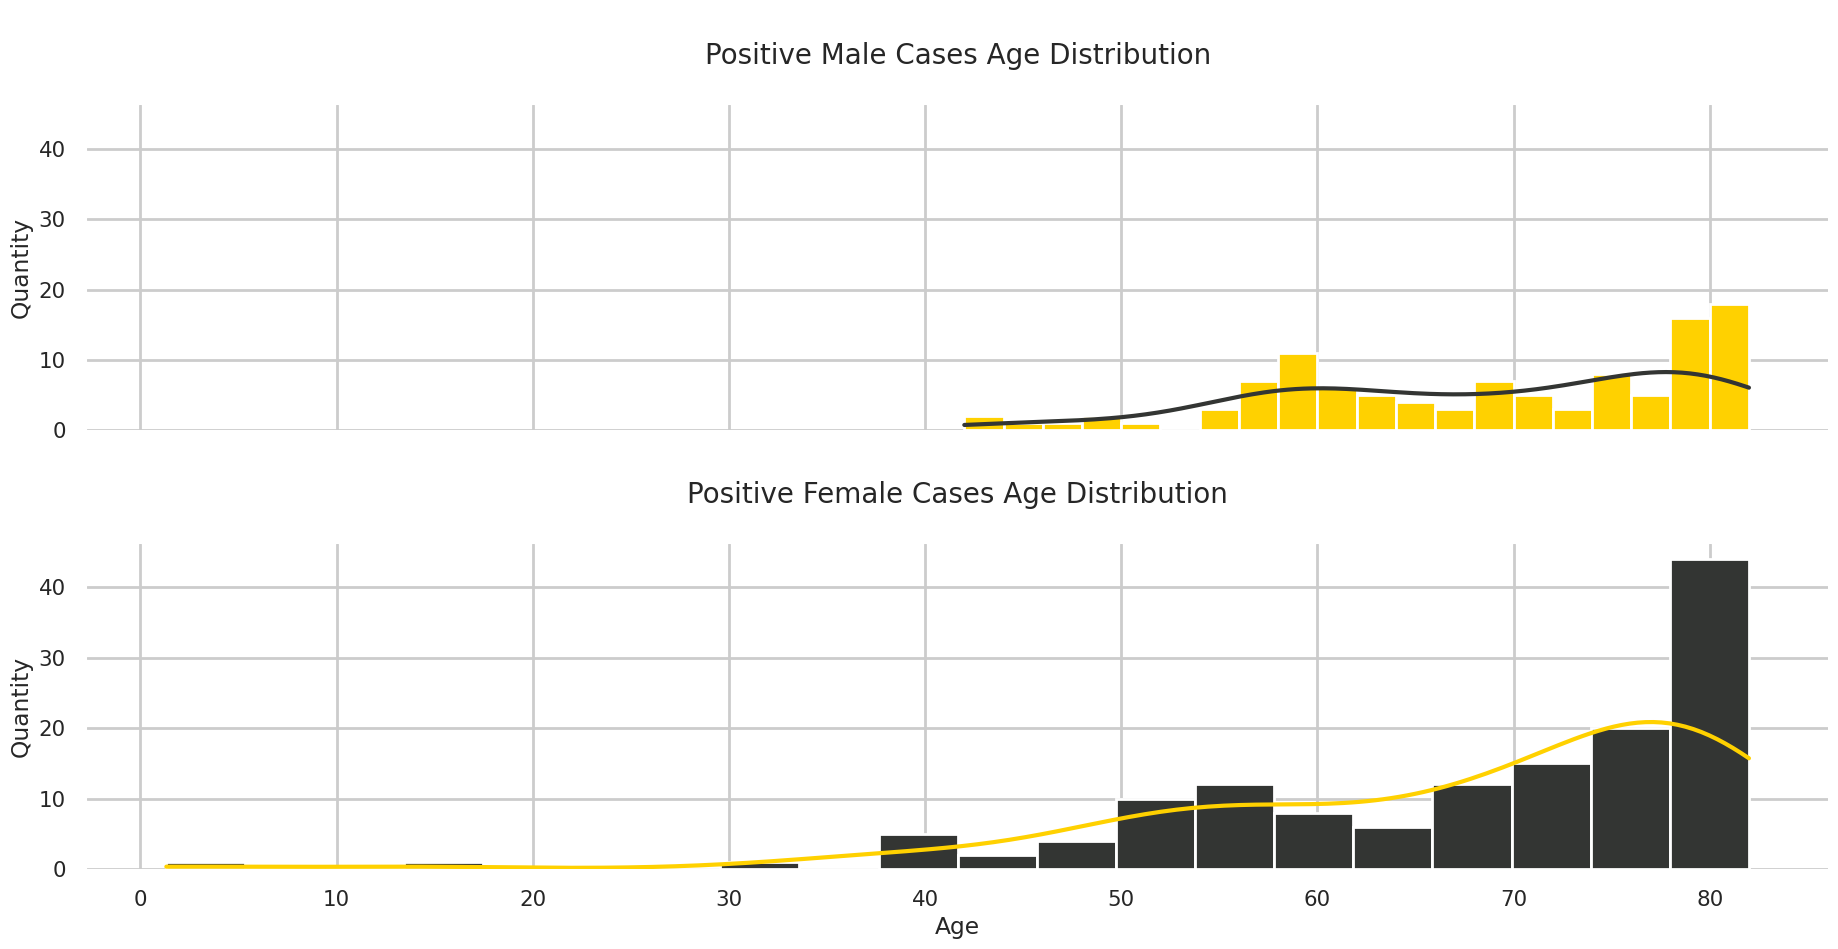

In [ ]:
_, axs = plt.subplots(2,1,figsize=(20,10),sharex=True,sharey=True)
plt.tight_layout(pad=4.0)

sns.histplot(data_positif[data_positif["gender"]=="Male"]["age"],color=palette[11],kde=True,ax=axs[0],bins=20,alpha=1,fill=True)
axs[0].lines[0].set_color(palette[12])
axs[0].set_title("\nPositive Male Cases Age Distribution\n",fontsize=20)
axs[0].set_xlabel("Age")
axs[0].set_ylabel("Quantity")

sns.histplot(data_positif[data_positif["gender"]=="Female"]["age"],color=palette[12],kde=True,ax=axs[1],bins=20,alpha=1,fill=True)
axs[1].lines[0].set_color(palette[11])
axs[1].set_title("\nPositive Female Cases Age Distribution\n",fontsize=20)
axs[1].set_xlabel("Age")
axs[1].set_ylabel("Quantity")

sns.despine(left=True, bottom=True)
plt.show()

In [ ]:
data_negatif = df[df["stroke"] == 0]

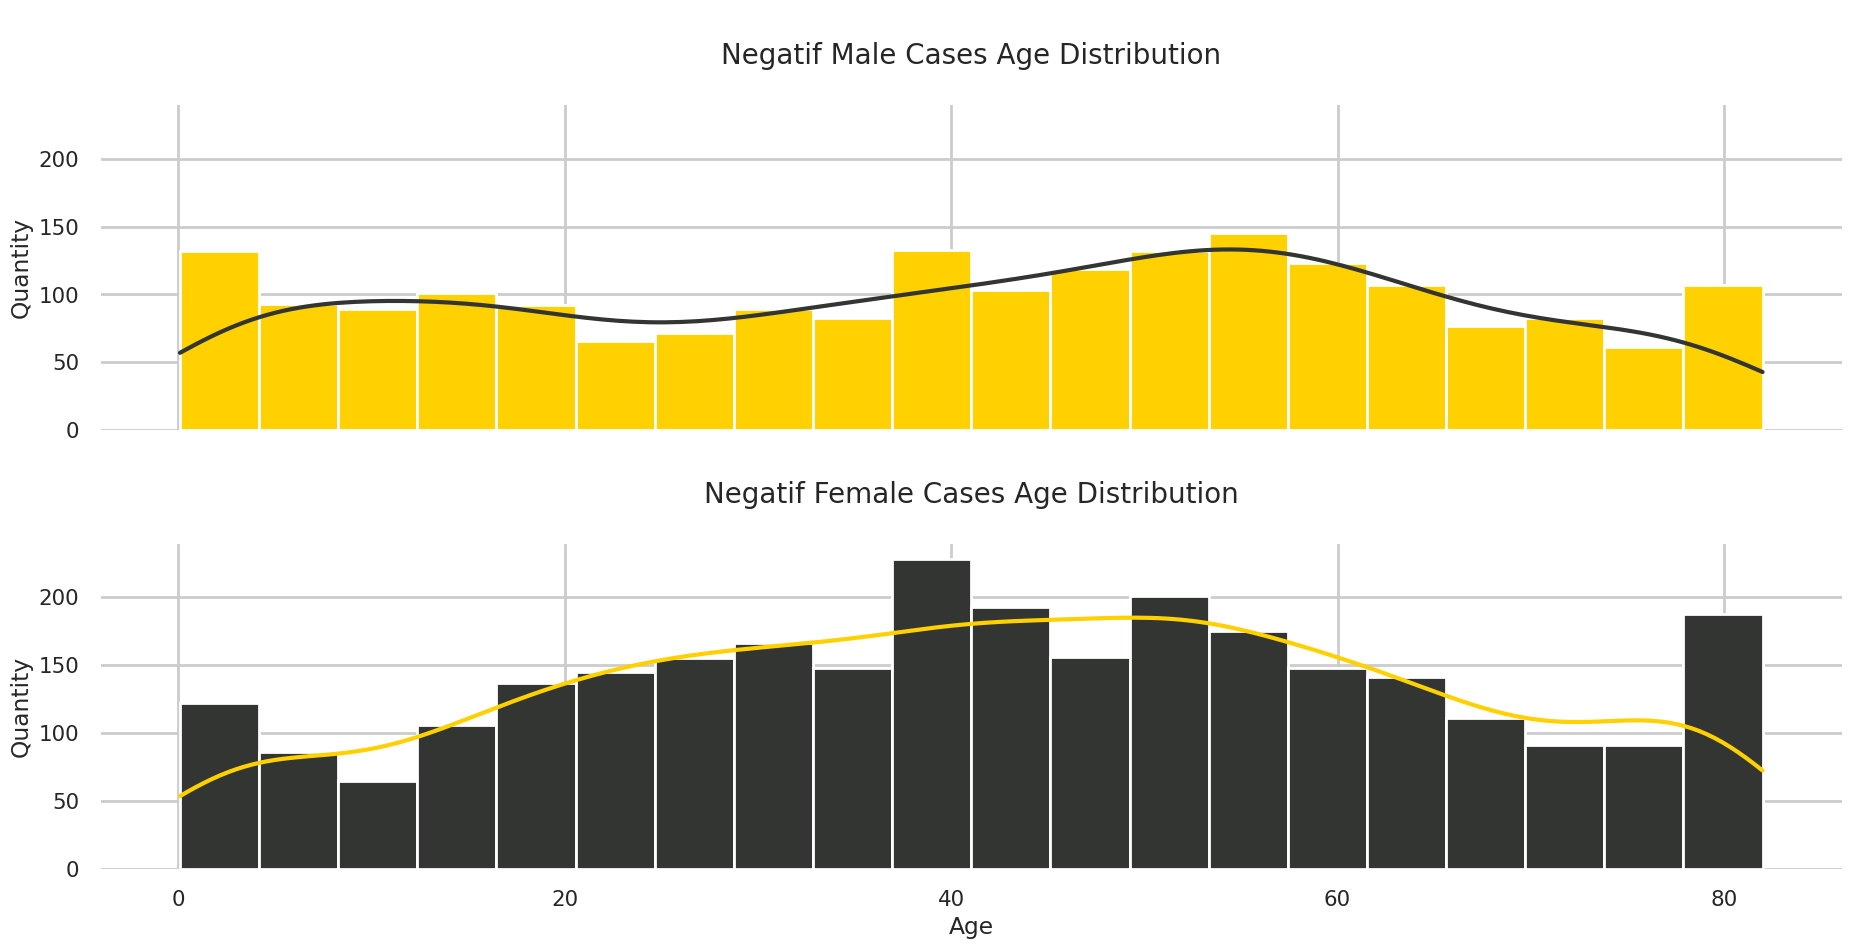

In [ ]:
_, axs = plt.subplots(2,1,figsize=(20,10),sharex=True,sharey=True)
plt.tight_layout(pad=4.0)

sns.histplot(data_negatif[data_negatif["gender"]=="Male"]["age"],color=palette[11],kde=True,ax=axs[0],bins=20,alpha=1,fill=True)
axs[0].lines[0].set_color(palette[12])
axs[0].set_title("\nNegatif Male Cases Age Distribution\n",fontsize=20)
axs[0].set_xlabel("Age")
axs[0].set_ylabel("Quantity")

sns.histplot(data_negatif[data_negatif["gender"]=="Female"]["age"],color=palette[12],kde=True,ax=axs[1],bins=20,alpha=1,fill=True)
axs[1].lines[0].set_color(palette[11])
axs[1].set_title("\nNegatif Female Cases Age Distribution\n",fontsize=20)
axs[1].set_xlabel("Age")
axs[1].set_ylabel("Quantity")

sns.despine(left=True, bottom=True)
plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5109 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5109 non-null   int64  
 1   gender             5109 non-null   object 
 2   age                5109 non-null   float64
 3   hypertension       5109 non-null   int64  
 4   heart_disease      5109 non-null   int64  
 5   ever_married       5109 non-null   object 
 6   work_type          5109 non-null   object 
 7   Residence_type     5109 non-null   object 
 8   avg_glucose_level  5109 non-null   float64
 9   bmi                4908 non-null   float64
 10  smoking_status     5109 non-null   object 
 11  stroke             5109 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 518.9+ KB


In [ ]:
list_replace = {
    "gender": {"Male": 0, "Female": 1},
    "ever_married":  {"No":0, "Yes":1},
    "work_type": {'Private':0, 'Self-employed': 1, 'children':2, 'Govt_job':3, 'Never_worked': 4},
    "Residence_type": {"Urban":0, "Rural": 1},
    "smoking_status": {'never smoked':0, 'Unknown': 1, 'formerly smoked': 2, 'smokes': 3}
}

clean_df = df.replace(list_replace)

<ipython-input-44-3ecc9b08b893>:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  clean_df = df.replace(list_replace)


In [ ]:
clean_df = clean_df[clean_df['bmi'].notna()]

In [ ]:
clean_df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,0,67.0,0,1,1,0,0,228.69,36.6,2,1
2,31112,0,80.0,0,1,1,0,1,105.92,32.5,0,1
3,60182,1,49.0,0,0,1,0,0,171.23,34.4,3,1
4,1665,1,79.0,1,0,1,1,1,174.12,24.0,0,1
5,56669,0,81.0,0,0,1,0,0,186.21,29.0,2,1


In [ ]:
X = clean_df.drop(columns=['stroke', "id"])
y = clean_df.stroke

In [ ]:
X

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status
0,0,67.0,0,1,1,0,0,228.69,36.6,2
2,0,80.0,0,1,1,0,1,105.92,32.5,0
3,1,49.0,0,0,1,0,0,171.23,34.4,3
4,1,79.0,1,0,1,1,1,174.12,24.0,0
5,0,81.0,0,0,1,0,0,186.21,29.0,2
...,...,...,...,...,...,...,...,...,...,...
5104,1,13.0,0,0,0,2,1,103.08,18.6,1
5106,1,81.0,0,0,1,1,0,125.20,40.0,0
5107,1,35.0,0,0,1,1,1,82.99,30.6,0
5108,0,51.0,0,0,1,0,1,166.29,25.6,2


## Decision Tree

In [ ]:
class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, gain=None, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.gain = gain
        self.value = value  # Only used for leaf nodes

    def is_leaf(self):
        return self.value is not None

In [ ]:
class DecisionTree():
  def __init__(self, min_samples=2, max_depth=2):
    self.min_samples = min_samples
    self.max_depth = max_depth

  # Spliting the data from parent to left and right node
  def split_data(self, dataset, feature, threshold):
    left_dataset = []
    right_dataset = []

    for row in dataset:
      if row[feature] <= threshold:
        left_dataset.append(row)
      else:
        right_dataset.append(row)

    left_dataset = np.array(left_dataset)
    right_dataset = np.array(right_dataset)

    return left_dataset, right_dataset

  # Calculation the value (0-1) entropy
  def entropy(self, y):
    entropy = 0

    labels = np.unique(y)

    for label in labels:
      label_examples = y[y == label]
      label_probability = len(label_examples) / len(y)
      entropy += -label_probability * np.log2(label_probability)

    return entropy

  # Calculation the value(0-1) of information before split and after
  def information_gain(self, parent, left_child, right_child):
    information_gain = 0

    parent_entropy = self.entropy(parent)

    weight_left = len(left_child) / len(parent)
    weight_right = len(right_child) / len(parent)

    entropy_left, entropy_right = self.entropy(left_child), self.entropy(right_child)

    weighted_entropy = weight_left * entropy_left + weight_right * entropy_right
    information_gain = parent_entropy - weighted_entropy

    return information_gain

  # search the best split for best information
  def best_split(self, dataset, num_samples, num_features):
    # dictionary to store the best split values
    best_split = {'gain':- 1, 'feature': None, 'threshold': None}
    # loop over all the features
    for feature_index in range(num_features):
        #get the feature at the current feature_index
        feature_values = dataset[:, feature_index]
        #get unique values of that feature
        thresholds = np.unique(feature_values)
        # loop over all values of the feature
        for threshold in thresholds:
            # get left and right datasets
            left_dataset, right_dataset = self.split_data(dataset, feature_index, threshold)
            # check if either datasets is empty
            if len(left_dataset) and len(right_dataset):
                # get y values of the parent and left, right nodes
                y, left_y, right_y = dataset[:, -1], left_dataset[:, -1], right_dataset[:, -1]
                # compute information gain based on the y values
                information_gain = self.information_gain(y, left_y, right_y)
                # update the best split if conditions are met
                if information_gain > best_split["gain"]:
                    best_split["feature"] = feature_index
                    best_split["threshold"] = threshold
                    best_split["left_dataset"] = left_dataset
                    best_split["right_dataset"] = right_dataset
                    best_split["gain"] = information_gain
    return best_split

  def calculate_leaf_value(self, y):
    """
    Calculates the most occurring value in the given list of y values.

    Args:
        y (list): The list of y values.

    Returns:
        The most occurring value in the list.
    """
    y = list(y)
    #get the highest present class in the array
    most_occuring_value = max(y, key=y.count)
    return most_occuring_value


  # Build tree for predict an entired data
  def build_tree(self, dataset, current_depth=0):
    X, y = dataset[:, :-1], dataset[:, -1]
    n_samples, n_features = X.shape

    if n_samples >= self.min_samples and current_depth <= self.max_depth:
        best_split = self.best_split(dataset, n_samples, n_features)

        # Check if gain is greater than 0 and left/right datasets are not empty
        if best_split["gain"] > 0 and len(best_split["left_dataset"]) > 0 and len(best_split["right_dataset"]) > 0:
            left_node = self.build_tree(best_split["left_dataset"], current_depth + 1)
            right_node = self.build_tree(best_split["right_dataset"], current_depth + 1)

            return Node(
                feature=best_split["feature"],
                threshold=best_split["threshold"],
                left=left_node,
                right=right_node,
                gain=best_split["gain"],
            )

    # If no valid split, create a leaf node
    leaf_value = self.calculate_leaf_value(y)
    return Node(value=leaf_value)

  def fit(self, X, y):
    """
    Builds and fits the decision tree to the given X and y values.

    Args:
    X (ndarray): The feature matrix.
    y (ndarray): The target values.
    """

    dataset = np.concatenate((X, y.reshape(-1, 1)), axis=1)
    self.root = self.build_tree(dataset)


  def predict(self, X):
    """
    Predicts the class labels for each instance in the feature matrix X.

    Args:
    X (ndarray): The feature matrix to make predictions for.

    Returns:
    list: A list of predicted class labels.
    """
    # Create an empty list to store the predictions
    predictions = []
    # For each instance in X, make a prediction by traversing the tree
    for x in X:
        prediction = self.make_prediction(x, self.root)
        # Append the prediction to the list of predictions
        predictions.append(prediction)
    # Convert the list to a numpy array and return it
    np.array(predictions)
    return predictions


  def make_prediction(self, x, node):
    """
    Traverses the decision tree to predict the target value for the given feature vector.

    Args:
    x (ndarray): The feature vector to predict the target value for.
    node (Node): The current node being evaluated.

    Returns:
    The predicted target value for the given feature vector.
    """

    # if the node has value i.e it's a leaf node extract it's value
    if node.value != None:
        return node.value
    else:
        #if it's node a leaf node we'll get it's feature and traverse through the tree accordingly
        feature = x[node.feature]
        if feature <= node.threshold:
            return self.make_prediction(x, node.left)
        else:
            return self.make_prediction(x, node.right)

## Random Forest

In [ ]:
class RandomForest():
    def __init__(self, n_trees=7, max_depth=7, min_samples=2):
      """
      Initialize the random forest classifier.

      Parameters
      ----------
      n_trees : int, default=7
          The number of trees in the random forest.
      max_depth : int, default=7
          The maximum depth of each decision tree in the random forest.
      min_samples : int, default=2
          The minimum number of samples required to split an internal node
          of each decision tree in the random forest.
      """
      self.n_trees = n_trees
      self.max_depth = max_depth
      self.min_samples = min_samples
      self.trees = []

    def fit(self, X, y):
        """
        Build a random forest classifier from the training set (X, y).

        Parameters
        ----------
        X : array-like of shape (n_samples, n_features)
            The training input samples.
        y : array-like of shape (n_samples,)
            The target values.

        Returns
        -------
        self : object
            Returns self.
        """

        # Create an empty list to store the trees.
        self.trees = []
        # Concatenate X and y into a single dataset.
        dataset = np.concatenate((X, y.reshape(-1, 1)), axis=1)
        # Loop over the number of trees.
        for _ in range(self.n_trees):
            # Create a decision tree instance.
            tree = DecisionTree(max_depth=self.max_depth, min_samples=self.min_samples)
            # Sample from the dataset with replacement (bootstrapping).
            dataset_sample = self.bootstrap_samples(dataset)
            # Get the X and y samples from the dataset sample.
            X_sample, y_sample = dataset_sample[:, :-1], dataset_sample[:, -1]
            # Fit the tree to the X and y samples.
            tree.fit(X_sample, y_sample)
            # Store the tree in the list of trees.
            self.trees.append(tree)
        return self

    def bootstrap_samples(self, dataset):
      """
      Bootstrap the dataset by sampling from it with replacement.

      Parameters
      ----------
      dataset : array-like of shape (n_samples, n_features + 1)
          The dataset to bootstrap.

      Returns
      -------
      dataset_sample : array-like of shape (n_samples, n_features + 1)
          The bootstrapped dataset sample.
      """

      # Get the number of samples in the dataset.
      n_samples = dataset.shape[0]
      # Generate random indices to index into the dataset with replacement.
      np.random.seed(1)
      indices = np.random.choice(n_samples, n_samples, replace=True)
      # Return the bootstrapped dataset sample using the generated indices.
      dataset_sample = dataset[indices]
      return dataset_sample

    def most_common_label(self, y):
      """
      Return the most common label in an array of labels.

      Parameters
      ----------
      y : array-like of shape (n_samples,)
          The array of labels.

      Returns
      -------
      most_occuring_value : int or float
          The most common label in the array.
      """
      y = list(y)
      # get the highest present class in the array
      most_occuring_value = max(y, key=y.count)
      return most_occuring_value

    def predict(self, X):
        """
        Predict class for X.

        Parameters
        ----------
        X : array-like of shape (n_samples, n_features)
            The input samples.

        Returns
        -------
        majority_predictions : array-like of shape (n_samples,)
            The predicted classes.
        """
        #get prediction from each tree in the tree list on the test data
        predictions = np.array([tree.predict(X) for tree in self.trees])
        print(predictions)
        print("After swaping ------------------------------")
        # get prediction for the same sample from all trees for each sample in the test data
        preds = np.swapaxes(predictions, 0, 1)
        print(preds)
        #get the most voted value by the trees and store it in the final predictions array
        majority_predictions = np.array([self.most_common_label(pred) for pred in preds])
        return majority_predictions

## Acuracy & Split

In [ ]:
def accuracy(y_true, y_pred):
    """
    Computes the accuracy of a classification model.

    Parameters:
    y_true (numpy array): A numpy array of true labels for each data point.
    y_pred (numpy array): A numpy array of predicted labels for each data point.

    Returns:
    float: The accuracy of the model, expressed as a percentage.
    """
    y_true = y_true.flatten()
    total_samples = len(y_true)
    correct_predictions = np.sum(y_true == y_pred)
    return (correct_predictions / total_samples)

In [ ]:
def train_test_split(X, y, random_state=42, test_size=0.2):
    """
    Splits the data into training and testing sets.

    Parameters:
        X (numpy.ndarray): Features array of shape (n_samples, n_features).
        y (numpy.ndarray): Target array of shape (n_samples,).
        random_state (int): Seed for the random number generator. Default is 42.
        test_size (float): Proportion of samples to include in the test set. Default is 0.2.

    Returns:
        Tuple[numpy.ndarray]: A tuple containing X_train, X_test, y_train, y_test.
    """
    # Get number of samples
    n_samples = X.shape[0]

    # Set the seed for the random number generator
    np.random.seed(random_state)

    # Shuffle the indices
    shuffled_indices = np.random.permutation(np.arange(n_samples))

    # Determine the size of the test set
    test_size = int(n_samples * test_size)

    # Split the indices into test and train
    test_indices = shuffled_indices[:test_size]
    train_indices = shuffled_indices[test_size:]

    # Split the features and target arrays into test and train
    X_train, X_test = X[train_indices], X[test_indices]
    y_train, y_test = y[train_indices], y[test_indices]

    return X_train, X_test, y_train, y_test

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X.to_numpy(), y.to_numpy(), test_size=.2, random_state=41)

## Predict

In [ ]:
# n_trees=7, max_depth=7, min_samples=2
model = RandomForest(10, 7, 2)

In [ ]:
model.fit(X_train, y_train)

predictions = model.predict(X_test)
accuracy(y_test, predictions)

[[0. 0. 0. ... 1. 0. 0.]
 [0. 0. 0. ... 1. 0. 0.]
 [0. 0. 0. ... 1. 0. 0.]
 ...
 [0. 0. 0. ... 1. 0. 0.]
 [0. 0. 0. ... 1. 0. 0.]
 [0. 0. 0. ... 1. 0. 0.]]
After swaping ------------------------------
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [1. 1. 1. ... 1. 1. 1.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


0.9307535641547862

In [ ]:
import numpy as np

In [ ]:
np.swapaxes(np.array([[10, 12, 17]]), 1, 0)

array([[10],
       [12],
       [17]])